In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
from pathlib import Path

# Define the base directory for data on the local SSD
LOCAL_SSD_BASE_DIR = Path('/content/deepfake_data')
LOCAL_SSD_BASE_DIR.mkdir(parents=True, exist_ok=True)

# Define the source paths in Google Drive
DRIVE_BASE_DIR = Path('/content/drive/MyDrive/NEW_DATASET_DEEPFAKE')

# Define destination directories on local SSD
LOCAL_HOLDOUT_DIR = LOCAL_SSD_BASE_DIR / "holdout_test"
LOCAL_BIDIRECTIONAL_OUTPUTS = LOCAL_SSD_BASE_DIR / "outputs" / "cross attention v1"
LOCAL_GATED_OUTPUTS = LOCAL_SSD_BASE_DIR / "outputs"
LOCAL_EVAL_OUTPUT_DIR = LOCAL_SSD_BASE_DIR / "holdout_evaluation" # New: Define evaluation output directory

# Create local SSD directories
LOCAL_HOLDOUT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_BIDIRECTIONAL_OUTPUTS.mkdir(parents=True, exist_ok=True)
LOCAL_GATED_OUTPUTS.mkdir(parents=True, exist_ok=True)
LOCAL_EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # New: Create evaluation output directory

print(f"Created local directories under: {LOCAL_SSD_BASE_DIR}")

Created local directories under: /content/deepfake_data


In [40]:
# Copy files from Google Drive to local SSD
import shutil
import zipfile # New: Import zipfile

# Holdout data - now handles hold_test.zip
ZIP_FILE_DRIVE_PATH = DRIVE_BASE_DIR / 'holdout_test.zip'
ZIP_FILE_LOCAL_PATH = LOCAL_SSD_BASE_DIR / 'holdout_test.zip'

print(f"Copying holdout_test.zip from {ZIP_FILE_DRIVE_PATH} to {ZIP_FILE_LOCAL_PATH}...")
shutil.copy(ZIP_FILE_DRIVE_PATH, ZIP_FILE_LOCAL_PATH)

# Unzip hold_test.zip into LOCAL_HOLDOUT_DIR
print(f"Extracting {ZIP_FILE_LOCAL_PATH} to {LOCAL_HOLDOUT_DIR}...")
with zipfile.ZipFile(ZIP_FILE_LOCAL_PATH, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_HOLDOUT_DIR)

# Bidirectional model
print(f"Copying bidirectional model from {DRIVE_BASE_DIR / 'outputs' / 'cross attention v1' / 'best.pt'} to {LOCAL_BIDIRECTIONAL_OUTPUTS}...")
shutil.copy(DRIVE_BASE_DIR / 'outputs' / 'cross_attention_v1' / 'best.pt', LOCAL_BIDIRECTIONAL_OUTPUTS)

# Gated model
print(f"Copying Gated model from {DRIVE_BASE_DIR /'best.pt'} to {LOCAL_GATED_OUTPUTS}...")
shutil.copy(DRIVE_BASE_DIR / 'best.pt', LOCAL_GATED_OUTPUTS)

print("All specified files copied/extracted to local SSD.")

Copying holdout_test.zip from /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/holdout_test.zip to /content/deepfake_data/holdout_test.zip...
Extracting /content/deepfake_data/holdout_test.zip to /content/deepfake_data/holdout_test...
Copying bidirectional model from /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs/cross attention v1/best.pt to /content/deepfake_data/outputs/cross attention v1...
Copying Gated model from /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/best.pt to /content/deepfake_data/outputs...
All specified files copied/extracted to local SSD.


In [41]:
from __future__ import annotations

import argparse
import csv
import gc
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset

from compare_models import load_torch_file, remove_prefixes
from test import build_model, crop_largest_face, make_transform, unpack_checkpoint


# ROOT = Path(__file__).resolve().parent # Original line
# ROOT = Path('/content') # Fixed: Set ROOT explicitly to the content directory for Colab
# ── Edit these paths for Colab or another machine ──────────────────────────
# Example Colab path: /content/drive/MyDrive/models/best.pt
HOLDOUT_DIR = LOCAL_HOLDOUT_DIR / "holdout_test" # Adjusted for nested directory structure
BIDIRECTIONAL_MODEL_PATH = LOCAL_BIDIRECTIONAL_OUTPUTS / 'best.pt'
GATED_MODEL_PATH = LOCAL_GATED_OUTPUTS / 'best.pt'
OUTPUT_DIR = LOCAL_EVAL_OUTPUT_DIR

# ──────────────────────────────────────────────────────────────────────────
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def collect_records(root: Path) -> list[dict]:
    """Discover real/fake images regardless of how deeply their folders nest."""
    records = []
    for class_name, label in (("real", 0), ("fake", 1)):
        class_dir = root / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(f"Expected folder not found: {class_dir}")
        for path in sorted(class_dir.rglob("*")):
            if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            relative = path.relative_to(class_dir)
            method = "real" if label == 0 else (relative.parts[0] if relative.parts else "unknown")
            records.append({"path": path, "label": label, "method": method})
    return records


class HoldoutDataset(Dataset):
    def __init__(self, records: list[dict], transform, use_face_crop: bool) -> None:
        self.records, self.transform, self.use_face_crop = records, transform, use_face_crop

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int):
        record = self.records[index]
        try:
            with Image.open(record["path"]) as opened:
                image = opened.convert("RGB")
            if self.use_face_crop:
                image = crop_largest_face(image, margin=0.35, min_face_size=48).image
            return self.transform(image), record["label"], record["method"], str(record["path"])
        except Exception as error:
            return None, str(record["path"]), str(error)


def collate_skip_errors(items):
    valid, failed = [], []
    for item in items:
        if item[0] is None:
            failed.append((item[1], item[2]))
        else:
            valid.append(item)
    if not valid:
        return None, failed
    images = torch.stack([item[0] for item in valid])
    labels = torch.tensor([item[1] for item in valid], dtype=torch.int64)
    methods = [item[2] for item in valid]
    paths = [item[3] for item in valid]
    return (images, labels, methods, paths), failed


def load_fusion_model(path: Path, device: torch.device):
    checkpoint = load_torch_file(path, device)
    state_dict, model_config = unpack_checkpoint(checkpoint)
    model = build_model(model_config, state_dict).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    saved_config = checkpoint.get("config", {}) if isinstance(checkpoint, dict) else {}
    image_size = int(saved_config.get("training", {}).get("image_size", 224)) if isinstance(saved_config, dict) else 224
    del checkpoint, state_dict
    return model, image_size


def evaluate_model(name, model, image_size, records, args, device):
    loader = DataLoader(
        HoldoutDataset(records, make_transform(image_size), args.face_crop),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.workers,
        pin_memory=device.type == "cuda",
        collate_fn=collate_skip_errors,
    )
    predictions, failed = [], []
    total_batches = len(loader)
    for batch_index, (batch, batch_failures) in enumerate(loader, start=1):
        failed.extend(batch_failures)
        if batch is None:
            continue
        images, labels, methods, paths = batch
        images = images.to(device, non_blocking=True)
        with torch.inference_mode():
            probabilities = torch.sigmoid(model(images)).flatten().cpu().tolist()
        for path, label, method, probability in zip(paths, labels.tolist(), methods, probabilities):
            predictions.append({
                "model": name, "path": path, "label": label, "method": method,
                "fake_probability": float(probability),
                "prediction": int(probability >= args.threshold),
            })
        if batch_index % 100 == 0 or batch_index == total_batches:
            print(f"  {name}: {batch_index}/{total_batches} batches")
    return predictions, failed


def calculate_metrics(predictions: list[dict]) -> dict:
    tp = sum(row["label"] == 1 and row["prediction"] == 1 for row in predictions)
    tn = sum(row["label"] == 0 and row["prediction"] == 0 for row in predictions)
    fp = sum(row["label"] == 0 and row["prediction"] == 1 for row in predictions)
    fn = sum(row["label"] == 1 and row["prediction"] == 0 for row in predictions)
    total = tp + tn + fp + fn
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    return {
        "evaluated": total, "accuracy": (tp + tn) / max(total, 1),
        "precision": precision, "recall": recall,
        "f1": 2 * precision * recall / max(precision + recall, 1e-12),
        "confusion_matrix": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    }


def plot_confusion_matrices(metrics: dict, output_dir: Path) -> None:
    figure, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4.5))
    if len(metrics) == 1:
        axes = [axes]
    for axis, (name, values) in zip(axes, metrics.items()):
        cm = values["confusion_matrix"]
        matrix = [[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]]
        image = axis.imshow(matrix, cmap="Blues")
        axis.set_xticks([0, 1], ["Pred REAL", "Pred FAKE"])
        axis.set_yticks([0, 1], ["Actual REAL", "Actual FAKE"])
        axis.set_title(f"{name}\nAccuracy: {values['accuracy'] * 100:.2f}%")
        for row in range(2):
            for column in range(2):
                color = "white" if matrix[row][column] > max(map(max, matrix)) / 2 else "black"
                axis.text(column, row, f"{matrix[row][column]:,}", ha="center", va="center", color=color, fontsize=12)
        figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    figure.tight_layout()
    figure.savefig(output_dir / "confusion_matrices.png", dpi=160, bbox_inches="tight")
    plt.close(figure)


def plot_metric_comparison(metrics: dict, output_dir: Path) -> None:
    names, fields = list(metrics), ("accuracy", "precision", "recall", "f1")
    positions = list(range(len(names)))
    width = 0.18
    figure, axis = plt.subplots(figsize=(10, 5))
    for index, field in enumerate(fields):
        offsets = [position + (index - 1.5) * width for position in positions]
        axis.bar(offsets, [metrics[name][field] * 100 for name in names], width, label=field.upper())
    axis.set_xticks(positions, names)
    axis.set_ylim(0, 100)
    axis.set_ylabel("Score (%)")
    axis.set_title("Holdout metrics: model comparison")
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_dir / "model_metrics.png", dpi=160, bbox_inches="tight")
    plt.close(figure)

def plot_per_method_recall(predictions_by_model: dict, output_dir: Path) -> None:
    methods = sorted({row["method"] for rows in predictions_by_model.values() for row in rows if row["label"] == 1})
    names = list(predictions_by_model)
    figure, axis = plt.subplots(figsize=(11, 5))
    width = 0.24
    for index, name in enumerate(names):
        rows = predictions_by_model[name]
        recalls = []
        for method in methods:
            subset = [row for row in rows if row["method"] == method and row["label"] == 1]
            recalls.append(100 * sum(row["prediction"] == 1 for row in subset) / max(len(subset), 1))
        offsets = [position + (index - (len(names) - 1) / 2) * width for position in range(len(methods))]
        axis.bar(offsets, recalls, width, label=name)
    axis.set_xticks(range(len(methods)), methods, rotation=20, ha="right")
    axis.set_ylim(0, 100)
    axis.set_ylabel("Fake recall (%)")
    axis.set_title("Fake recall by manipulation method")
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_dir / "per_method_fake_recall.png", dpi=160, bbox_inches="tight")
    plt.close(figure)


def write_csv(path: Path, rows: list[dict]) -> None:
    if not rows:
        return
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)


def main(args_override: list[str] | None = None) -> None:
    parser = argparse.ArgumentParser(description="Evaluate all three detectors on holdout_test.")
    parser.add_argument("--dataset", default=str(HOLDOUT_DIR), help="Dataset root containing real/ and fake/.")
    parser.add_argument("--output", default=str(OUTPUT_DIR), help="Folder for metrics, CSV files, and charts.")
    parser.add_argument("--bidirectional", default=str(BIDIRECTIONAL_MODEL_PATH), help="Bidirectional best.pt path.")
    parser.add_argument("--gated", default=str(GATED_MODEL_PATH), help="Gated best.pt path.")
    parser.add_argument("--batch-size", type=int, default=4, help="Inference batch size; lower it if GPU memory is insufficient.")
    parser.add_argument("--workers", type=int, default=2, help="Image-loader worker processes. Use 0 if Windows has issues.")
    parser.add_argument("--threshold", type=float, default=0.5)
    parser.add_argument("--face-crop", action="store_true", help="Detect and crop a face before inference; slower but matches face-crop training.")
    parser.add_argument("--limit", type=int, default=None, help="Optional limit for a quick test run.")
    args = parser.parse_args(args_override)
    if args.batch_size < 1 or args.workers < 0 or not 0 <= args.threshold <= 1:
        parser.error("Invalid batch size, worker count, or threshold.")

    dataset_root, output_dir = Path(args.dataset), Path(args.output)
    records = collect_records(dataset_root)
    if args.limit:
        records = records[:args.limit]
    counts = defaultdict(int)
    for record in records:
        counts["FAKE" if record["label"] else "REAL"] += 1
    print(f"Found {len(records):,} images: {counts['REAL']:,} real, {counts['FAKE']:,} fake")
    print(f"Face crop: {'enabled' if args.face_crop else 'disabled'}")

    output_dir.mkdir(parents=True, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    loaders = {
        "Bidirectional": (load_fusion_model, Path(args.bidirectional)),
        "Gated": (load_fusion_model, Path(args.gated)),
    }
    all_predictions, all_failures, metrics = {}, [], {}
    for name, (loader, checkpoint_path) in loaders.items():
        if not checkpoint_path.is_file():
            raise FileNotFoundError(f"{name} model file not found: {checkpoint_path}")
        print(f"\nLoading {name}: {checkpoint_path}")
        model, image_size = loader(checkpoint_path, device)
        predictions, failures = evaluate_model(name, model, image_size, records, args, device)
        all_predictions[name] = predictions
        all_failures.extend(failures)
        metrics[name] = calculate_metrics(predictions)
        print(f"{name}: accuracy={metrics[name]['accuracy'] * 100:.2f}%  F1={metrics[name]['f1'] * 100:.2f}%")
        del model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    combined_predictions = [row for rows in all_predictions.values() for row in rows]
    write_csv(output_dir / "per_image_predictions.csv", combined_predictions)
    write_csv(output_dir / "skipped_images.csv", [{"path": path, "error": error} for path, error in all_failures])
    with (output_dir / "metrics.json").open("w", encoding="utf-8") as file:
        json.dump(metrics, file, indent=2)
    metric_rows = [{"model": name, **{key: value for key, value in values.items() if key != "confusion_matrix"}, **values["confusion_matrix"]} for name, values in metrics.items()]
    write_csv(output_dir / "metrics.csv", metric_rows)
    plot_confusion_matrices(metrics, output_dir)
    plot_metric_comparison(metrics, output_dir)
    plot_per_method_recall(all_predictions, output_dir)
    print(f"\nSaved results and charts to: {output_dir}")


if __name__ == "__main__":
    main(args_override=[]) # Pass an empty list to prevent IPython from passing its own args

Found 28,766 images: 4,800 real, 23,966 fake
Face crop: disabled
Device: cuda

Loading Bidirectional: /content/deepfake_data/outputs/cross attention v1/best.pt
  Bidirectional: 100/7192 batches
  Bidirectional: 200/7192 batches
  Bidirectional: 300/7192 batches
  Bidirectional: 400/7192 batches
  Bidirectional: 500/7192 batches
  Bidirectional: 600/7192 batches
  Bidirectional: 700/7192 batches
  Bidirectional: 800/7192 batches
  Bidirectional: 900/7192 batches
  Bidirectional: 1000/7192 batches
  Bidirectional: 1100/7192 batches
  Bidirectional: 1200/7192 batches
  Bidirectional: 1300/7192 batches
  Bidirectional: 1400/7192 batches
  Bidirectional: 1500/7192 batches
  Bidirectional: 1600/7192 batches
  Bidirectional: 1700/7192 batches
  Bidirectional: 1800/7192 batches
  Bidirectional: 1900/7192 batches
  Bidirectional: 2000/7192 batches
  Bidirectional: 2100/7192 batches
  Bidirectional: 2200/7192 batches
  Bidirectional: 2300/7192 batches
  Bidirectional: 2400/7192 batches
  Bidirec

### Evaluation Metrics

In [42]:
import pandas as pd
import json
from IPython.display import Image, display

# Display metrics.csv
metrics_df = pd.read_csv(LOCAL_EVAL_OUTPUT_DIR / "metrics.csv")
print("Metrics CSV:")
display(metrics_df)


Metrics CSV:


,model,evaluated,accuracy,precision,recall,f1,tn,fp,fn,tp
0,Bidirectional,28766,0.954703,0.979194,0.966160,0.972634,4308,492,811,23155
1,Gated,28766,0.921783,0.987518,0.917717,0.951339,4522,278,1972,21994


In [43]:
# Display metrics.json
with open(LOCAL_EVAL_OUTPUT_DIR / "metrics.json", "r") as f:
    metrics_json = json.load(f)
print("\nMetrics JSON:")
display(metrics_json)



Metrics JSON:


{'Bidirectional': {'evaluated': 28766,
  'accuracy': 0.954703469373566,
  'precision': 0.9791939780944728,
  'recall': 0.9661603938913461,
  'f1': 0.9726335244576061,
  'confusion_matrix': {'tn': 4308, 'fp': 492, 'fn': 811, 'tp': 23155}},
 'Gated': {'evaluated': 28766,
  'accuracy': 0.9217826600848223,
  'precision': 0.9875179597701149,
  'recall': 0.917716765417675,
  'f1': 0.9513387257234309,
  'confusion_matrix': {'tn': 4522, 'fp': 278, 'fn': 1972, 'tp': 21994}}}

### Generated Plots

Confusion Matrices:


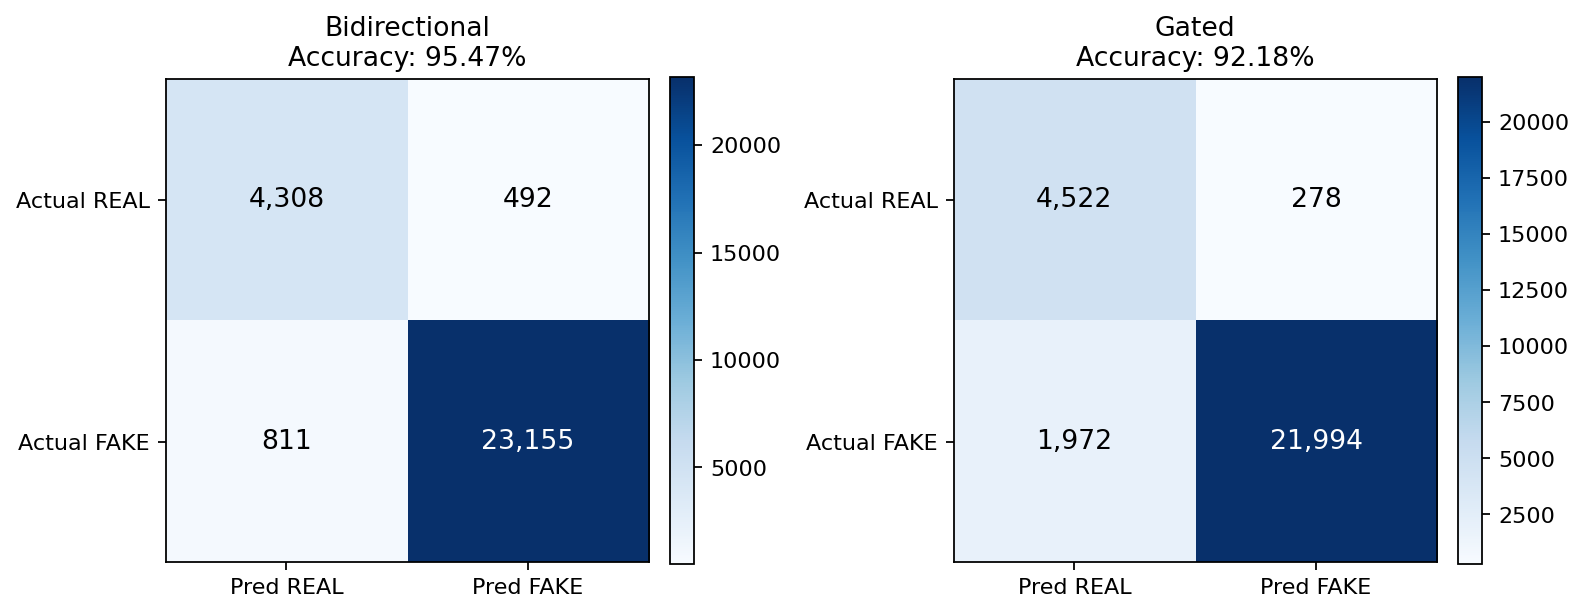


Model Comparison Metrics:


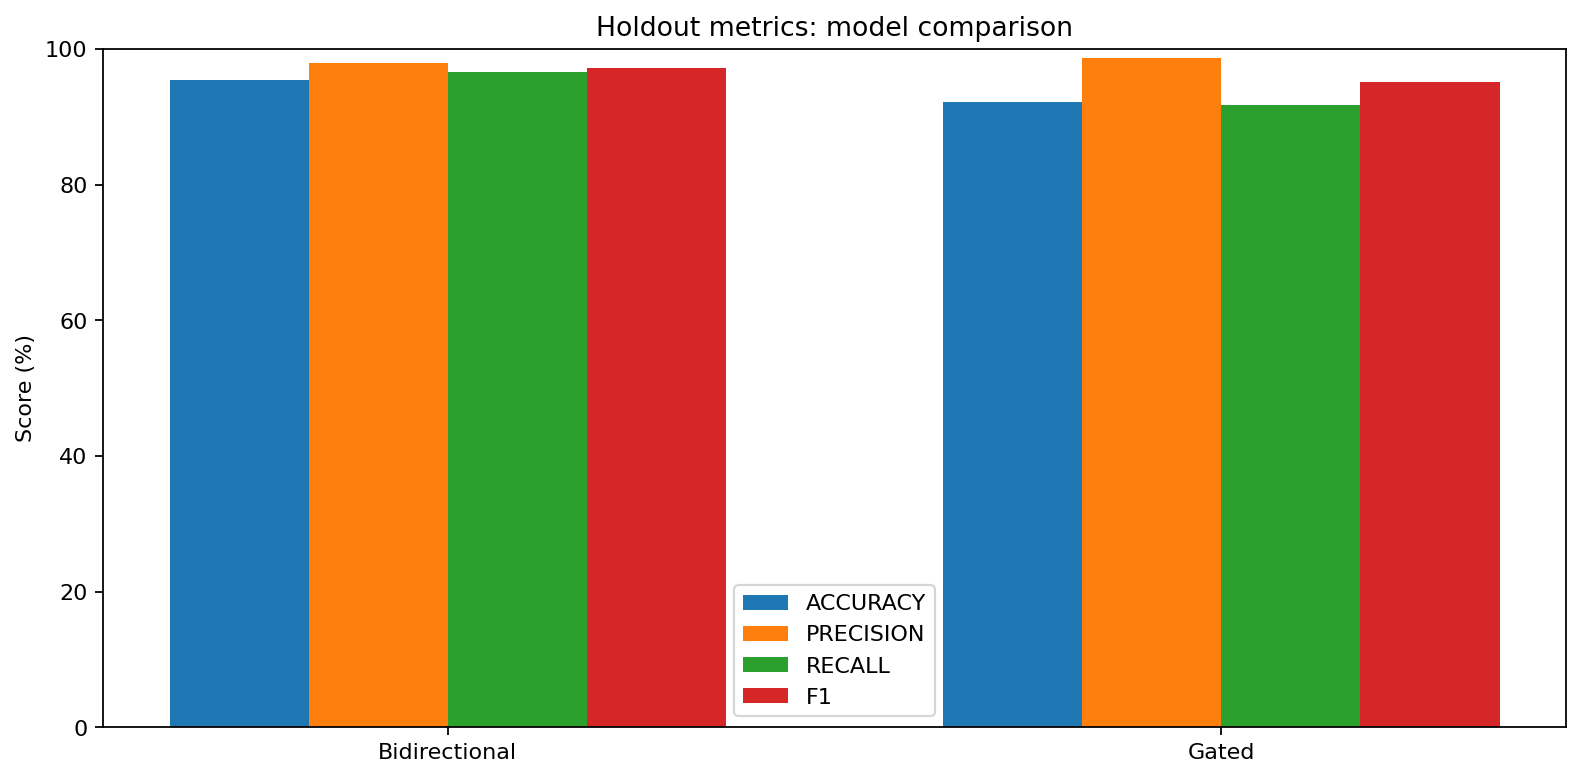


Per-Method Fake Recall:


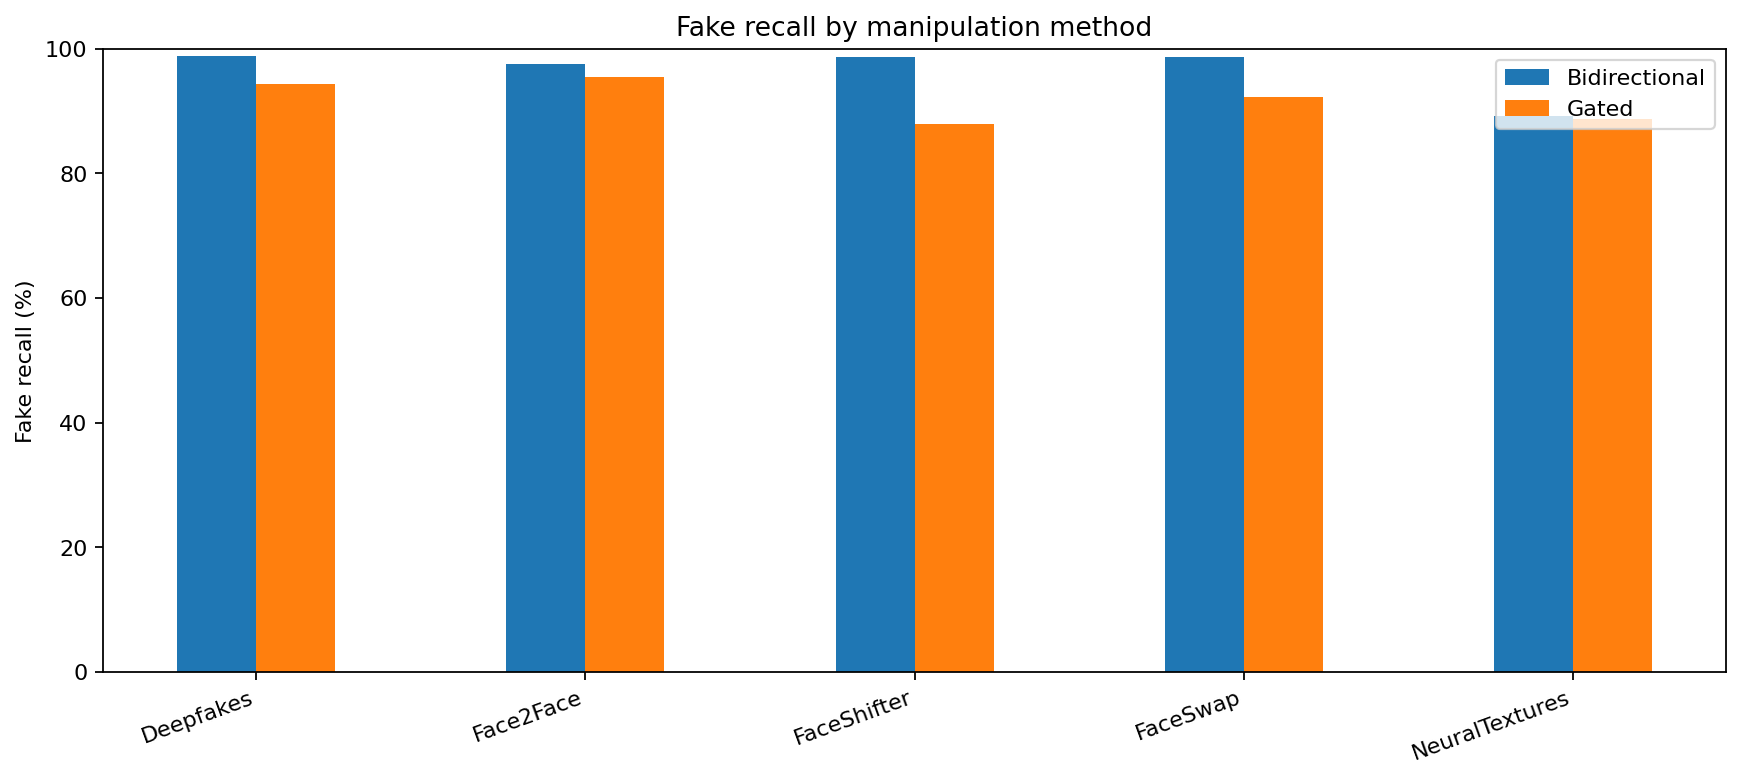

In [44]:
# Display confusion_matrices.png
print("Confusion Matrices:")
display(Image(filename=LOCAL_EVAL_OUTPUT_DIR / "confusion_matrices.png"))

# Display model_metrics.png
print("\nModel Comparison Metrics:")
display(Image(filename=LOCAL_EVAL_OUTPUT_DIR / "model_metrics.png"))

# Display per_method_fake_recall.png
print("\nPer-Method Fake Recall:")
display(Image(filename=LOCAL_EVAL_OUTPUT_DIR / "per_method_fake_recall.png"))


### Single Image Prediction

Using device: cuda

Evaluating image 1: output.jpg


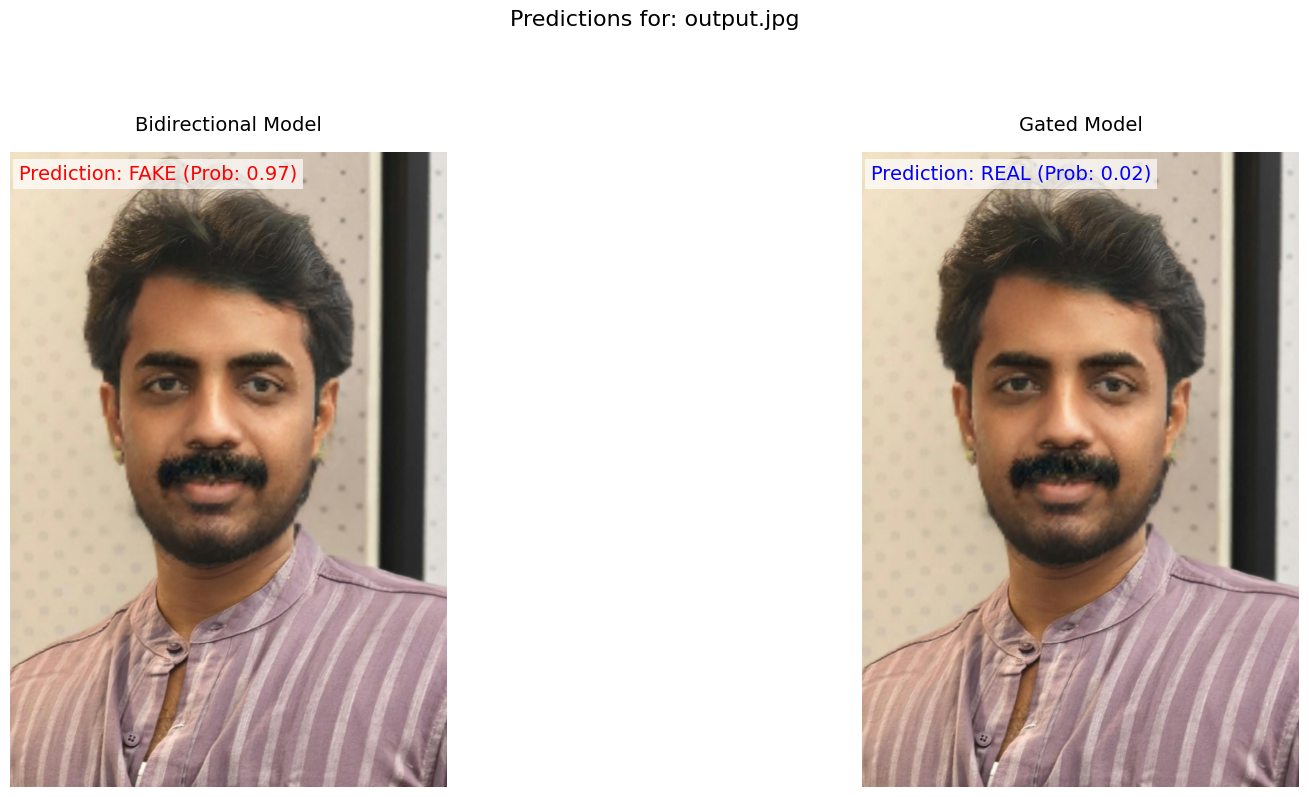

In [53]:
import torch
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure helper modules are accessible (already done by earlier cell, but good for self-containment)
import sys
if str(Path('/content')) not in sys.path:
    sys.path.insert(0, str(Path('/content')))

# Import necessary functions from previously loaded helper scripts
from compare_models import load_torch_file, remove_prefixes
from test import build_model, crop_largest_face, make_transform, unpack_checkpoint

# Redefine load_fusion_model for self-containment in this cell
def load_fusion_model(path: Path, device: torch.device):
    checkpoint = load_torch_file(path, device)
    state_dict, model_config = unpack_checkpoint(checkpoint)
    model = build_model(model_config, state_dict).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    saved_config = checkpoint.get("config", {}) if isinstance(checkpoint, dict) else {}
    image_size = int(saved_config.get("training", {}).get("image_size", 224)) if isinstance(saved_config, dict) else 224
    del checkpoint, state_dict
    return model, image_size, saved_config

def predict_single_image(
    image_path: Path,
    model_path: Path,
    device: torch.device,
    use_face_crop: bool = False
) -> float:
    """Performs inference on a single image and returns the fake probability."""

    # Load model and get image size
    model, image_size, model_config = load_fusion_model(model_path, device)

    # Prepare transform based on model's expected image size
    transform = make_transform(image_size)

    try:
        with Image.open(image_path) as opened:
            image = opened.convert("RGB")

        if use_face_crop:
            image = crop_largest_face(image, margin=0.35, min_face_size=48).image
            if image is None: # If no face is detected after cropping attempt
                print(f"Warning: No face detected in {image_path}. Skipping face crop.")
                # Re-open original image if face crop failed, or handle as error
                with Image.open(image_path) as opened_original:
                    image = opened_original.convert("RGB")

        # Apply transformations and add batch dimension
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.inference_mode():
            raw_prediction = model(image_tensor)
            probability = torch.sigmoid(raw_prediction).item()

        del model # Clean up model from GPU memory
        if device.type == "cuda":
            torch.cuda.empty_cache()

        return probability

    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return -1.0 # Indicate an error

# --- User adjustable settings ---
# IMPORTANT: Replace with the actual path to your images in Google Drive
IMAGE_PATHS = [
    Path('/content/drive/MyDrive/NEW_DATASET_DEEPFAKE/output.jpg') # Only the first image path
]
USE_FACE_CROP_FOR_SINGLE_PREDICTION = False # Set to True if the models were trained with face cropping

# --- Inference and Visualization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

predictions_data = []

for i, SINGLE_IMAGE_PATH in enumerate(IMAGE_PATHS):
    print(f"\nEvaluating image {i+1}: {SINGLE_IMAGE_PATH.name}")

    if not SINGLE_IMAGE_PATH.exists():
        print(f"Error: Image file not found at {SINGLE_IMAGE_PATH}. Skipping this image.")
        predictions_data.append(None)
        continue

    # Bidirectional Model Prediction
    bidirectional_prob = predict_single_image(
        SINGLE_IMAGE_PATH,
        LOCAL_BIDIRECTIONAL_OUTPUTS / 'best.pt',
        device,
        USE_FACE_CROP_FOR_SINGLE_PREDICTION
    )

    # Gated Model Prediction
    gated_prob = predict_single_image(
        SINGLE_IMAGE_PATH,
        LOCAL_GATED_OUTPUTS / 'best.pt',
        device,
        USE_FACE_CROP_FOR_SINGLE_PREDICTION
    )

    predictions_data.append({
        'path': SINGLE_IMAGE_PATH,
        'bidirectional_prob': bidirectional_prob,
        'gated_prob': gated_prob
    })

# --- Visualize Predictions on Images ---
num_images = len(predictions_data)
if num_images == 0:
    print("No images to display.")
else:
    # Create 2 subplots for each image (one for bidirectional, one for gated)
    # Now, it will be 1 image * 2 plots = 2 plots total
    fig, axes = plt.subplots(1, 2, figsize=(10 * 2, 8)) # Increased figure width
    # 'axes' is already a 1D numpy array of Axes objects when plt.subplots(1, 2) is called.
    # No special handling to make it a list is needed here, as it's already iterable.

    current_plot_index = 0
    for data in predictions_data:
        if data is None:
            # Handle 'Image not found' for both model slots
            for _ in range(2):
                axes[current_plot_index].text(0.5, 0.5, "Image not found", horizontalalignment='center', verticalalignment='center', transform=axes[current_plot_index].transAxes, fontsize=16, color='red')
                axes[current_plot_index].axis('off')
                current_plot_index += 1
            continue

        SINGLE_IMAGE_PATH = data['path']
        bidirectional_prob = data['bidirectional_prob']
        gated_prob = data['gated_prob']

        try:
            img = Image.open(SINGLE_IMAGE_PATH).convert("RGB")

            # Set a suptitle for the image filename, centered above both plots
            fig.suptitle(f"Predictions for: {SINGLE_IMAGE_PATH.name}", fontsize=16, y=1.02) # Adjust y for spacing

            # Bidirectional Plot for the current image
            ax_bidirectional = axes[current_plot_index]
            ax_bidirectional.imshow(img)
            ax_bidirectional.axis('off')
            if bidirectional_prob != -1.0:
                bidirectional_prediction_text = f"Prediction: {'FAKE' if bidirectional_prob >= 0.5 else 'REAL'} (Prob: {bidirectional_prob:.2f})"
                ax_bidirectional.text(0.02, 0.98, bidirectional_prediction_text, color='red', fontsize=14,
                                      bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                                      transform=ax_bidirectional.transAxes, ha='left', va='top') # Relative positioning
            ax_bidirectional.set_title("Bidirectional Model", fontsize=14, pad=15) # Only model name, pad title
            current_plot_index += 1

            # Gated Plot for the current image
            ax_gated = axes[current_plot_index]
            ax_gated.imshow(img)
            ax_gated.axis('off')
            if gated_prob != -1.0:
                gated_prediction_text = f"Prediction: {'FAKE' if gated_prob >= 0.5 else 'REAL'} (Prob: {gated_prob:.2f})"
                ax_gated.text(0.02, 0.98, gated_prediction_text, color='blue', fontsize=14,
                              bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                              transform=ax_gated.transAxes, ha='left', va='top') # Relative positioning
            ax_gated.set_title("Gated Model", fontsize=14, pad=15) # Only model name, pad title
            current_plot_index += 1

        except Exception as e:
            print(f"Error displaying image {SINGLE_IMAGE_PATH.name} with predictions: {e}")
            for _ in range(2): # Occupy both slots if image fails to load/display
                axes[current_plot_index].text(0.5, 0.5, f"Error loading image: {e}", horizontalalignment='center', verticalalignment='center', transform=axes[current_plot_index].transAxes, fontsize=12, color='red')
                axes[current_plot_index].axis('off')
                current_plot_index += 1

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

### Ensure Python can find helper modules
To resolve the `ModuleNotFoundError` for `compare_models` and `test`, we'll explicitly add the current directory (`/content`) to Python's system path.

In [46]:
import sys
from pathlib import Path

# Ensure /content is in sys.path so helper modules can be imported
if str(Path('/content')) not in sys.path:
    sys.path.insert(0, str(Path('/content')))

print(f"sys.path updated: {sys.path}")

sys.path updated: ['/content', '/env/python', '/usr/lib/python313.zip', '/usr/lib/python3.13', '/usr/lib/python3.13/lib-dynload', '', '/usr/local/lib/python3.13/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.13/dist-packages/IPython/extensions', '/root/.ipython']


In [47]:
get_ipython().system('ls /content/drive')

MyDrive
